In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df = pd.read_csv("data/superstore_cleaned.csv", index_col = "Row ID")

#re-do what i did in the EDA file
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Postal Code"] = df["Postal Code"].astype(str)
df["Order Date Year"] = df["Order Date"].dt.year
df["Order Date Month"] = df["Order Date"].dt.strftime("%b")
df["Order Date Month No"] = df["Order Date"].dt.month

#sorting by "Order Date Month No" to get the months sorted from January - December
df = df.sort_values("Order Date Month No")

#Sorting the month using "Order Date Month No" column, then grouping it by year using for loop
years = [2015, 2016, 2017, 2018]
dfs = {}

for year in years:
    dfs[year] = df[df["Order Date Year"] == year].copy()

In [3]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Date Year,Order Date Month,Order Date Month No
Row ID,,,,,,,,,,,,,,,,,,,,
9800,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384,2016,Jan,1
7476,CA-2015-167199,2015-01-06,2015-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420.0,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2015,Jan,1
7475,CA-2015-167199,2015-01-06,2015-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,2015,Jan,1
5030,CA-2018-139304,2018-01-29,2018-02-02,Standard Class,VG-21790,Vivek Gonzalez,Consumer,United States,San Francisco,California,94109.0,West,OFF-AR-10001216,Office Supplies,Art,Newell 339,8.340,2018,Jan,1
2376,CA-2018-119669,2018-01-24,2018-01-30,Standard Class,TP-21130,Theone Pippenger,Consumer,United States,Smyrna,Georgia,30080.0,South,OFF-FA-10000053,Office Supplies,Fasteners,Revere Boxed Rubber Bands by Revere,5.670,2018,Jan,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4226,US-2015-102631,2015-12-13,2015-12-17,Standard Class,EB-13840,Ellis Ballard,Corporate,United States,Chicago,Illinois,60623.0,Central,FUR-FU-10003930,Furniture,Furnishings,Howard Miller 12-3/4 Diameter Accuwave DS Wal...,94.428,2015,Dec,12
4240,CA-2018-158673,2018-12-29,2019-01-04,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Grand Rapids,Michigan,49505.0,Central,OFF-PA-10000994,Office Supplies,Paper,Xerox 1915,209.700,2018,Dec,12
4249,CA-2017-157336,2017-12-01,2017-12-05,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Fairfield,Connecticut,6824.0,East,OFF-BI-10004236,Office Supplies,Binders,"XtraLife ClearVue Slant-D Ring Binder, White, 3""",88.080,2017,Dec,12


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 9788 entries, 9800 to 4896
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             9788 non-null   str           
 1   Order Date           9788 non-null   datetime64[us]
 2   Ship Date            9788 non-null   datetime64[us]
 3   Ship Mode            9788 non-null   str           
 4   Customer ID          9788 non-null   str           
 5   Customer Name        9788 non-null   str           
 6   Segment              9788 non-null   str           
 7   Country              9788 non-null   str           
 8   City                 9788 non-null   str           
 9   State                9788 non-null   str           
 10  Postal Code          9788 non-null   str           
 11  Region               9788 non-null   str           
 12  Product ID           9788 non-null   str           
 13  Category             9788 non-null   str      

**I want to try to visualize it first before combining it, so here's the ROUGH VERSION + INSIGHTS:**

## Chart 1 : Total Sales by Category (2015-2018)

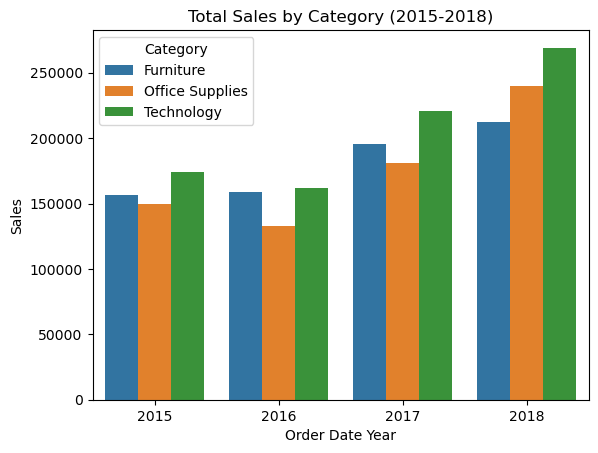

In [5]:
df_cat_year = df.pivot_table(
    index = "Order Date Year",
    columns = "Category",
    values = "Sales",
    aggfunc = "sum"
)

df_cat_year_melted = df_cat_year.reset_index().melt(
    id_vars = "Order Date Year",
    var_name = "Category",
    value_name = "Sales",
)

sns.barplot(
    data = df_cat_year_melted,
    x = "Order Date Year",
    y = "Sales",
    hue = "Category",
)

plt.title("Total Sales by Category (2015-2018)")
plt.show()

> Insight : Technology is the fastest growing category, overtaking Furniture in 2017 and consistently grow over time. in 2016, Office Supplies dropped nearly 25K of sales before it escalated and became the second position in 2018. The sales on Furniture is stagnant compared to other categories, the marketing team should consider reviewing the pricing strategy to achieve growth in the following years.

## Chart 2 : Median Monthly Sales Trend (2015 - 2018)

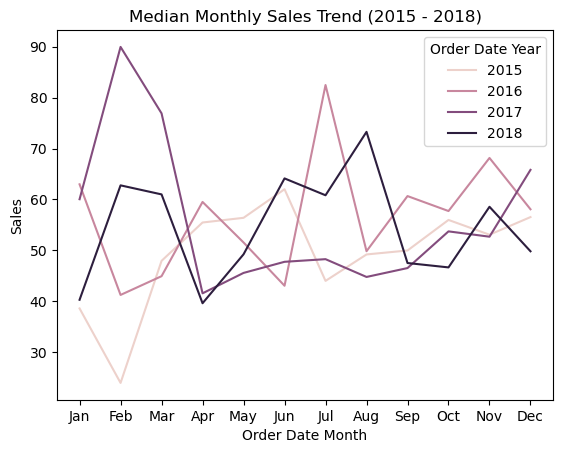

In [6]:
df_year_sales = df.pivot_table(
    index = ["Order Date Month No", "Order Date Month"],
    columns = "Order Date Year",
    values = "Sales",
    aggfunc = "median"
).sort_index().droplevel("Order Date Month No")

df_year_sales_melted = df_year_sales.reset_index().melt(
    id_vars = "Order Date Month",
    var_name = "Order Date Year",
    value_name = "Sales",
)

sns.lineplot(
    data = df_year_sales_melted,
    x = "Order Date Month",
    y = "Sales",
    hue = "Order Date Year",
)

plt.title("Median Monthly Sales Trend (2015 - 2018)")
plt.show()

>Insight : The sales from June to August consistently represents the peak period where companies should prioritize targeted promotions, except in 2017, which peaked in February instead and dropped dramatically in the next 2 months. Although the overall trend shows an inconsistent trend across all 4 years, the constant drop in April 2017 requires further investigation on the root cause of this anomaly.

## Chart 3 : Top 10 Sub-Categories by Sales

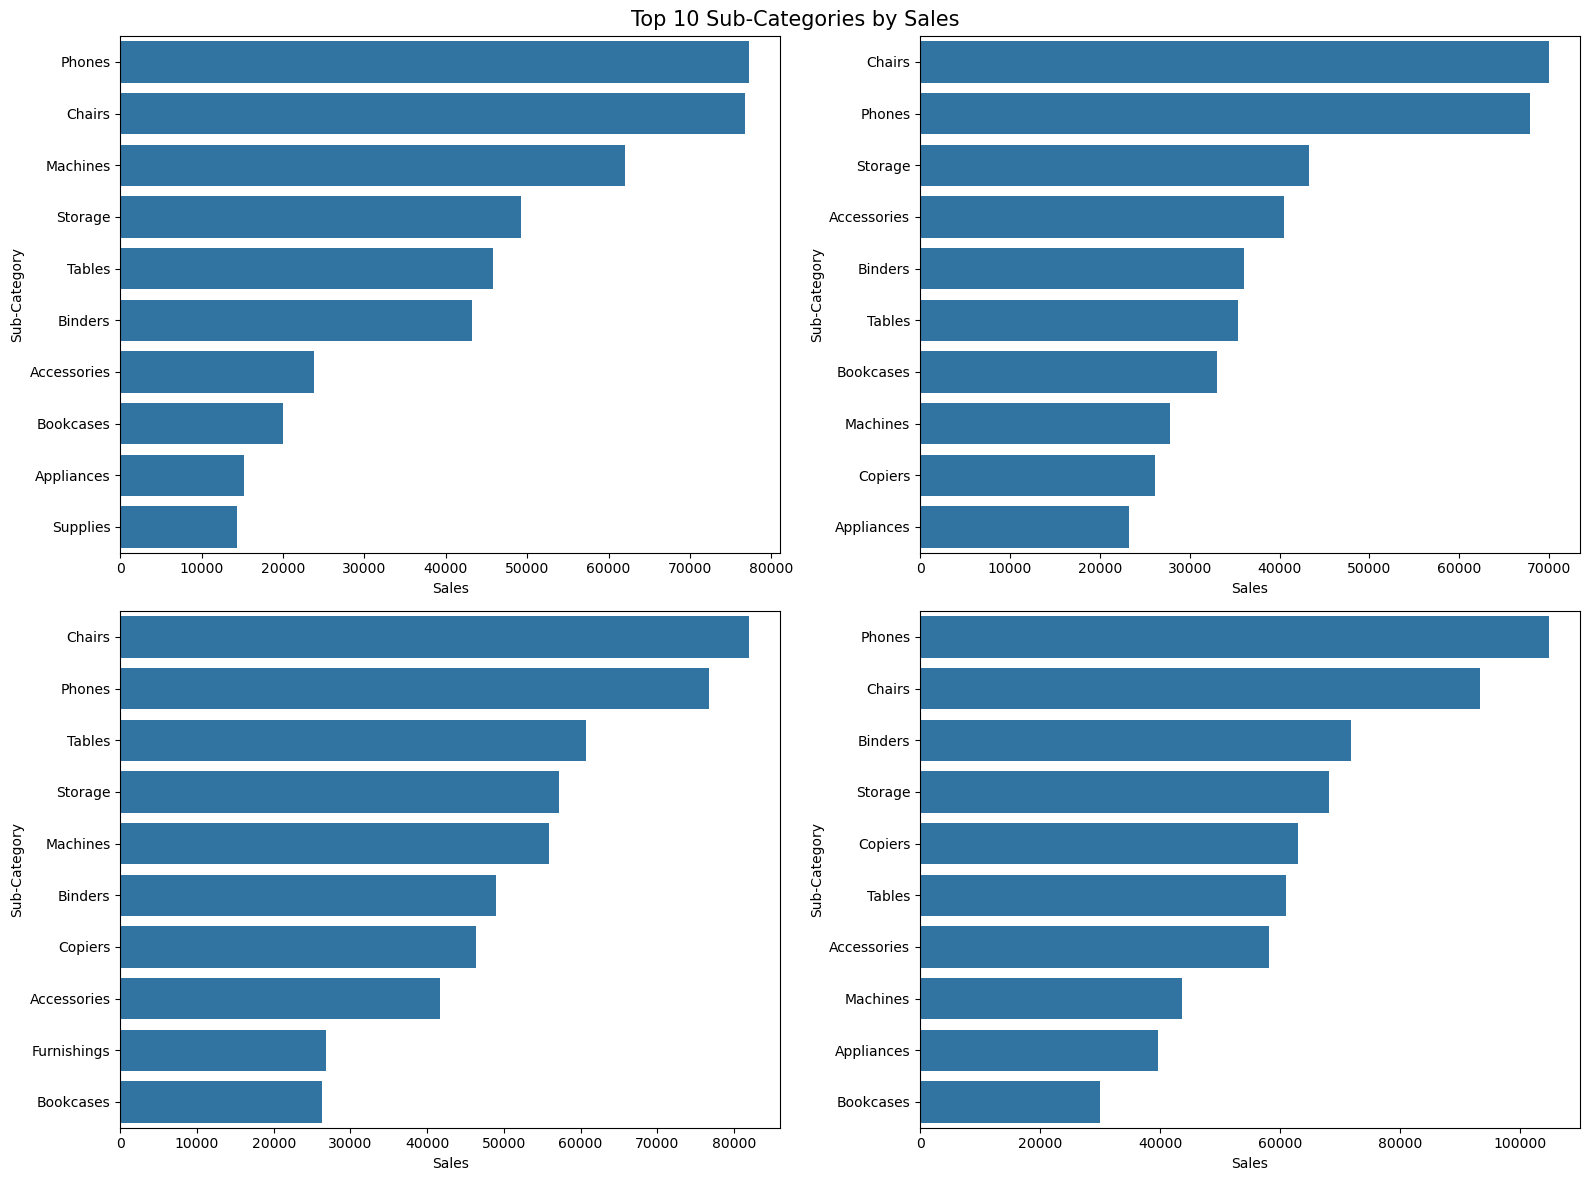

In [7]:
fig, ax = plt.subplots(2,2, figsize = (16, 12))

years = [2015, 2016, 2017, 2018]
df_subcat = {}

for i, year in enumerate (years):
    df_subcat[year] = dfs[year].groupby("Sub-Category")["Sales"].sum().sort_values(ascending = False).head(10).reset_index()
    sns.barplot(
        data = df_subcat[year],
        x = "Sales",
        y = "Sub-Category",
        ax = ax[i//2, i%2],
    )


fig.suptitle("Top 10 Sub-Categories by Sales", fontsize = 15)
plt.tight_layout()
plt.show()

> Insight : Phones and Chairs consistently taking turns as the top 2 sub-categories across all 4 years, showing stable demand in Technology accessories and Furniture. On the other hand, other categories like Supplies and Appliances sits relatively low on the rank. The business should consider whether these categories are worth maintaining in the catalog or more efforts should be made to boost the marketing.

## Chart 4 : Sales Contribution by Segment (2015 - 2018)

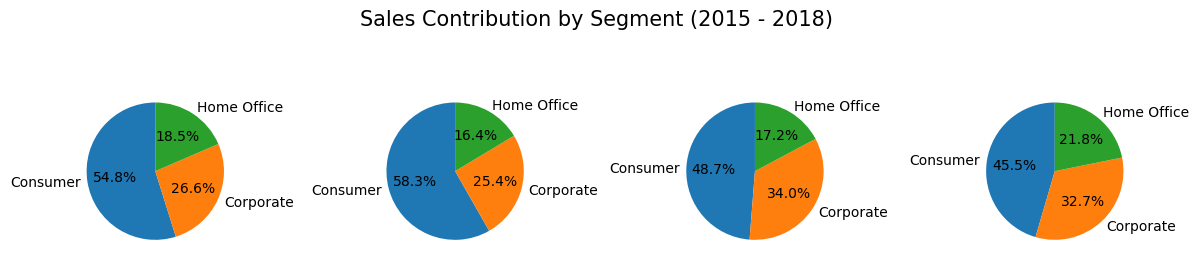

In [8]:
fig, ax = plt.subplots(1,4, figsize = (12, 3))

years = [2015, 2016, 2017, 2018]
df_sales_segment = {}

for i, year in enumerate(years):
    df_sales_segment[year] = dfs[year].groupby("Segment")["Sales"].sum()
    df_sales_segment[year].plot(
        kind = "pie",
        ax = ax[i],
        startangle = 90,
        autopct = "%1.1f%%"
        )
    
fig.suptitle("Sales Contribution by Segment (2015 - 2018)", fontsize = 15)
plt.tight_layout()

>Insight : Consumers stayed as the top contributor to the company followed by Corporate while Home Office sales remained at nearly 1/4 by 2018. Throughout all 4 years, Corporate is growing while Consumer is shrinking from more than 53% in the start of the period to less than half the sales in 2018. The business owner should maintain Consumers as the main source of high sales but also starts promoting marketing that attracts Corporate to achieve high sales.

## Chart 5 : Top 5 States by Number of Orders per Region

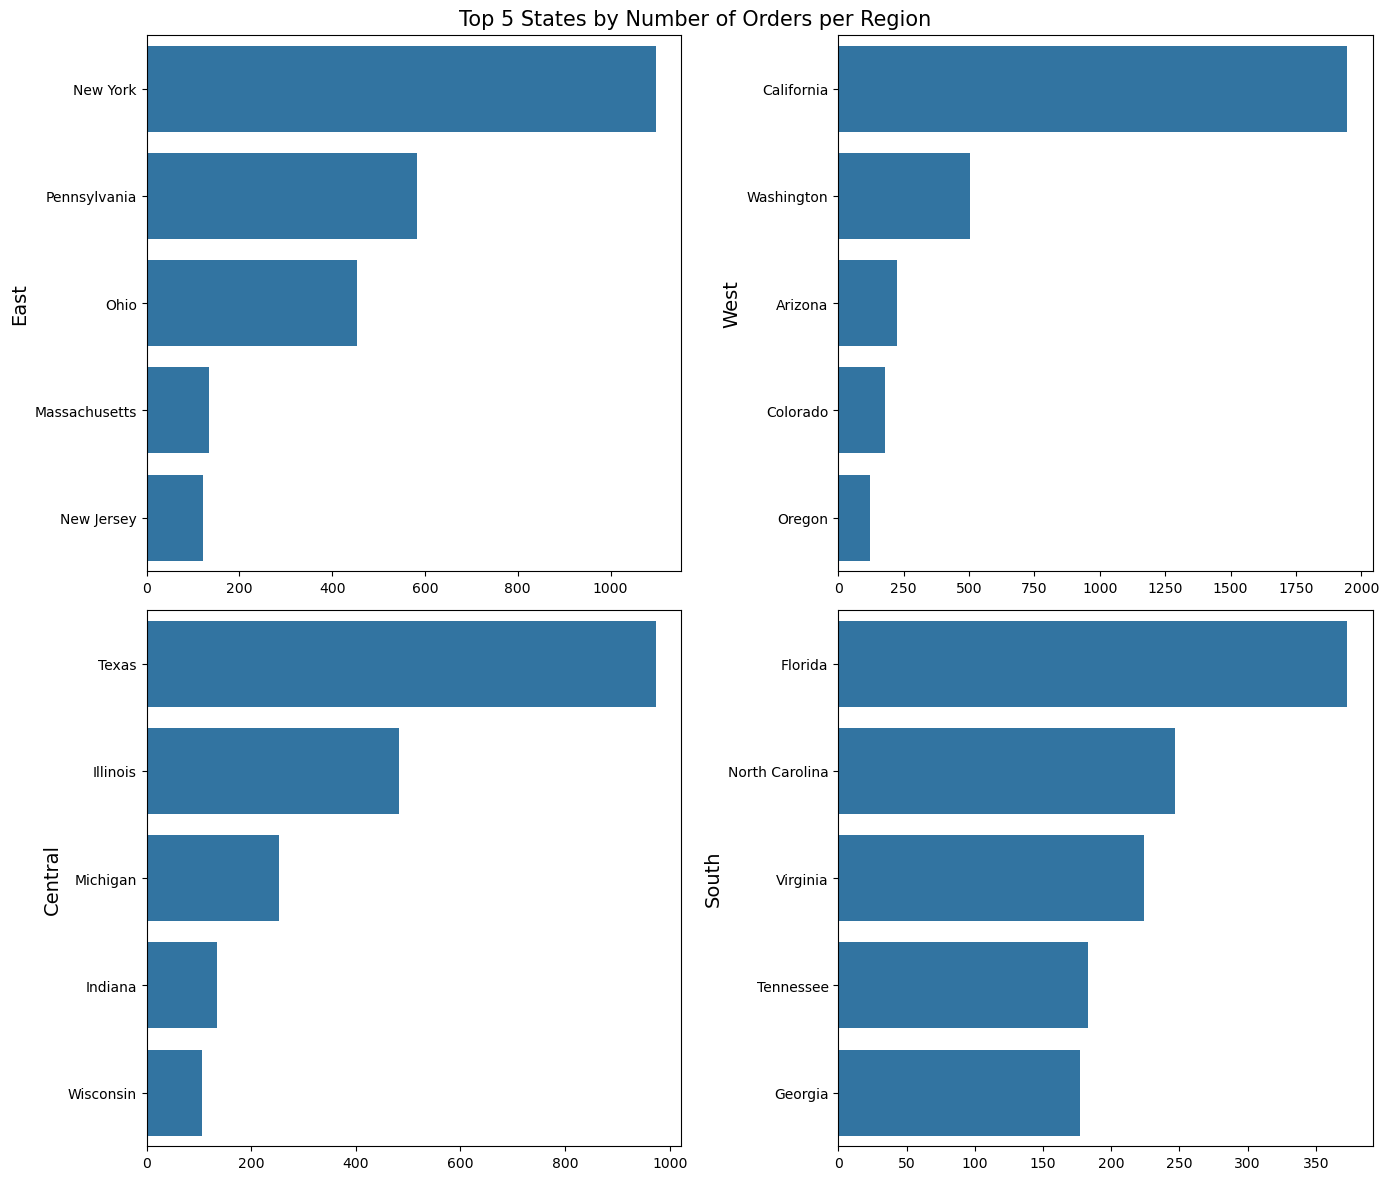

In [9]:
fig, ax = plt.subplots(2, 2, figsize = (14, 12))

Regions = ["East", "West", "Central", "South"]
df_region = {}

for i, region in enumerate(Regions):
    df_region[region] = df[df["Region"] == region]["State"].value_counts().head().reset_index()
    current_ax = ax[i//2, i%2]
    sns.barplot(
        data = df_region[region],
        x = "count",
        y = "State",
        ax = current_ax
    )
    current_ax.set_ylabel(region, fontsize = 14)
    current_ax.set_xlabel("")


fig.suptitle("Top 5 States by Number of Orders per Region", fontsize = 15)
plt.tight_layout()


>Insight : In general, California dominated the sales with nearly 2000 orders in total followed by New York (East) and Texas (Central). Although Florida dominated the number of orders in the South, overall, it is the most evenly distributed region compared to the others especially West where its extremely top heavy. The company should consider reviewing the states in the West to investigate on the large gap between California and other states. 

## Chart 6 : Sales Distribution by Ship Mode and Segment

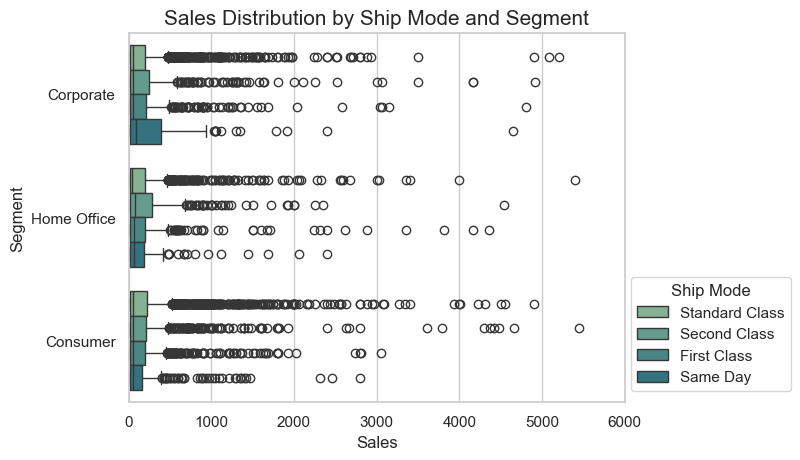

In [21]:
sns.boxplot(
    data = df,
    x = "Sales",
    y = "Segment",
    hue = "Ship Mode"
)
plt.legend(
    loc = "lower right",
    bbox_to_anchor = (1.35, 0.01),
    title = "Ship Mode"
)

plt.title("Sales Distribution by Ship Mode and Segment", fontsize = 15)
plt.xlim(0, 6000)
plt.show()

>Insight : It shows that most orders vary between $0 to nearly $500 with numerous outliers scattered around $1000 to $2000 and some even reaching $5000. Across all three segments, same day delivery shows sales consistency in around $500 to approximately $2500 while standard class has the widest range of sales. To maintain a consistent order value distribution, the large outliers in standard class orders suggest the business should investigate more on the reason behind these high-value orders. 

# Superstore Sales Dashboard (2015 - 2018)

## First Dashboard
>**Sales Performance**

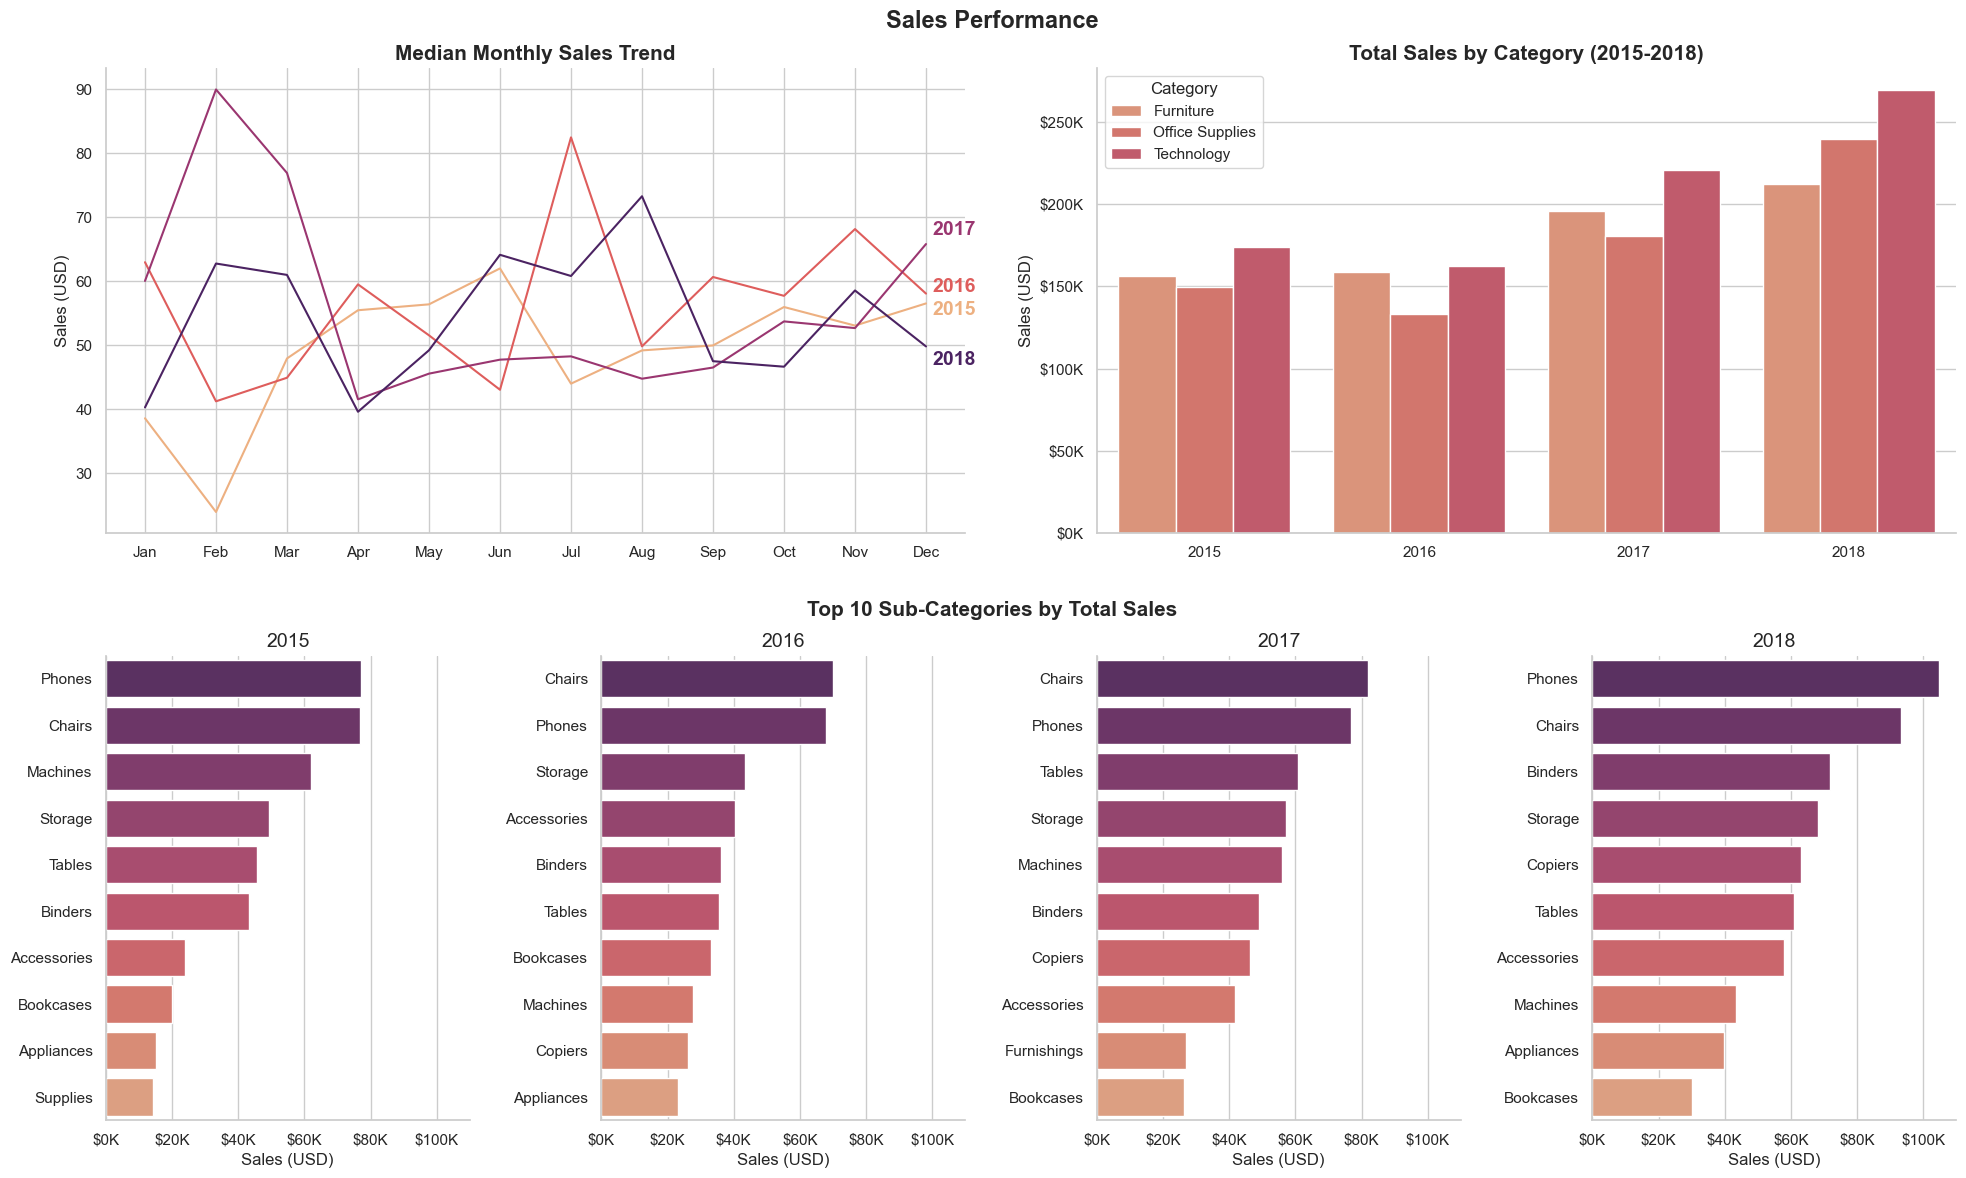

In [27]:
sns.set_theme(style = "whitegrid", palette = "flare")
fig1 = plt.figure(figsize = (20, 12))
gs1 = gridspec.GridSpec(2, 4, figure = fig1)

#Initiate the axes
chart2 = fig1.add_subplot(gs1[0, 0:2])
chart1 = fig1.add_subplot(gs1[0, 2:4])
chart3_2015 = fig1.add_subplot(gs1[1, 0])
chart3_2016 = fig1.add_subplot(gs1[1, 1])
chart3_2017 = fig1.add_subplot(gs1[1, 2])
chart3_2018 = fig1.add_subplot(gs1[1, 3])

#--------------------------------------------------------------------------#

#=== CHART 2 : Median Monthly Sales Trend (2015 - 2018) ====
sns.lineplot(
    data = df_year_sales_melted,
    x = "Order Date Month",
    y = "Sales",
    hue = "Order Date Year",
    ax = chart2,
    palette = "flare"
)
chart2.set_title("Median Monthly Sales Trend", fontsize = 15, fontweight = "bold")
chart2.set_xlabel("")
chart2.set_ylabel("Sales (USD)", fontsize = 12)
chart2.legend().set_visible(False)

#Creating the legend to appear at the end of its corresponding line
lines = chart2.get_lines()
labels = ["2015", "2016", "2017", "2018"]
offsets = [-5, 5, 10, -10]

for line, label, offset in zip (lines, labels, offsets):
    y = line.get_ydata()[-1]
    x = line.get_xdata()[-1]
    chart2.annotate(
        label,
        xy = (x, y),
        xytext = (5, offset),
        textcoords = "offset points",
        va = "center",
        fontsize = 14,
        fontweight = "bold",
        color = line.get_color()
    )

#--------------------------------------------------------------------------#

#=== CHART 1 : Total Sales by Category (2015-2018) ====
sns.barplot(
    data = df_cat_year_melted,
    x = "Order Date Year",
    y = "Sales",
    hue = "Category",
    ax = chart1,
)
chart1.set_title("Total Sales by Category (2015-2018)", fontsize = 15, fontweight = "bold")
chart1.set_xlabel("")
chart1.set_ylabel("Sales (USD)", fontsize = 12)
chart1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

#--------------------------------------------------------------------------#

#=== CHART3 : Top 10 Sub-Categories by Sales ====
chart3_axes = [chart3_2015, chart3_2016, chart3_2017, chart3_2018]

for ax, year in zip (chart3_axes, years):
    df_subcat[year] = dfs[year].groupby("Sub-Category")["Sales"].sum().sort_values(ascending = False).head(10).reset_index()
    sns.barplot(
        data = df_subcat[year],
        x = "Sales",
        y = "Sub-Category",
        hue = "Sub-Category",
        ax = ax,
        palette = "flare_r",
        legend = False
    )
    ax.set_title(str(year), fontsize = 14)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
    ax.set_xlabel("Sales (USD)", fontsize = 12)
    ax.set_ylabel("")

#Making all 4 charts have the same limit as chart3_2018
shared_xlim1 = chart3_2018.get_xlim()
for ax in chart3_axes:
    ax.set_xlim(shared_xlim1)

#Title of the third chart
fig1.text(0.5, 0.475, "Top 10 Sub-Categories by Total Sales", ha = "center", fontsize = 15, fontweight = "bold")

#--------------------------------------------------------------------------#

plt.suptitle("Sales Performance", fontsize = 17, fontweight = "bold")
plt.subplots_adjust(hspace=50)
plt.subplots_adjust(wspace=10)
sns.despine()
plt.tight_layout()
plt.show()

fig1.savefig("dashboard1.png", dpi = 150, bbox_inches = "tight")

## Second Dashboard
> **Regional Segment Analysis**

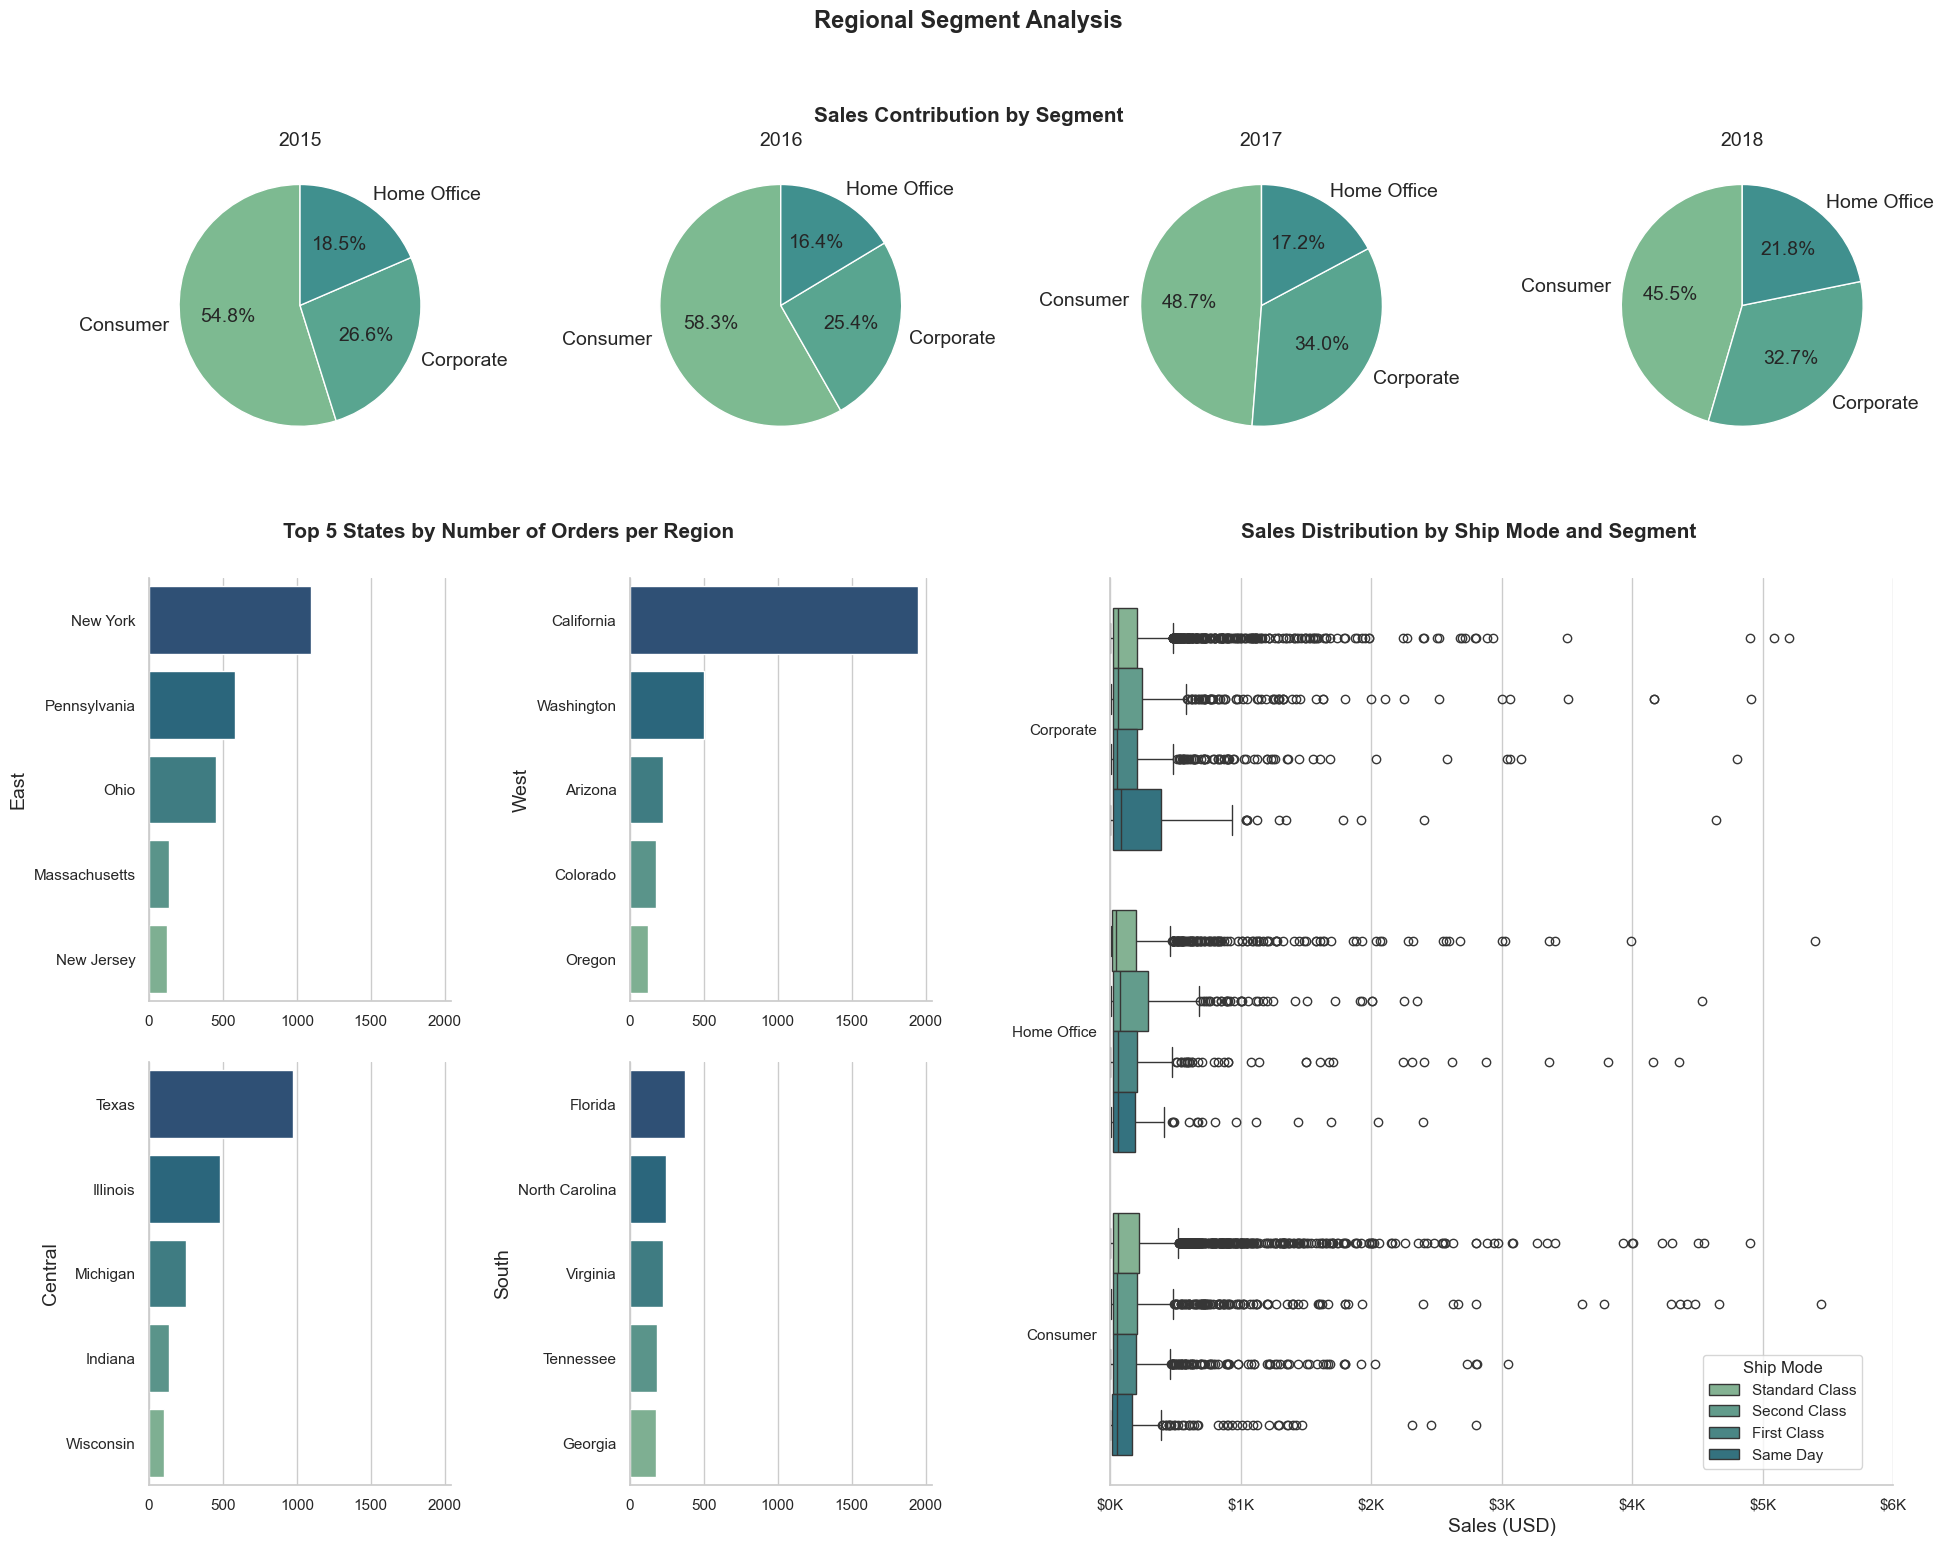

In [ ]:
sns.set_theme(style = "whitegrid", palette = "crest")
fig2 = plt.figure(figsize = (20, 16))
gs2 = gridspec.GridSpec(3, 4, figure = fig2)

#Initiate the axes
chart4_2015 = fig2.add_subplot(gs2[0, 0])
chart4_2016 = fig2.add_subplot(gs2[0, 1])
chart4_2017 = fig2.add_subplot(gs2[0, 2])
chart4_2018 = fig2.add_subplot(gs2[0, 3])
chart5_east = fig2.add_subplot(gs2[1, 0])
chart5_west = fig2.add_subplot(gs2[1, 1])
chart5_central = fig2.add_subplot(gs2[2, 0])
chart5_south = fig2.add_subplot(gs2[2, 1])
chart6 = fig2.add_subplot(gs2[1:3, 2:4])

#--------------------------------------------------------------------------#

#=== CHART 4 : Sales Contribution by Segment (2015 - 2018) ====
chart4_axes = [chart4_2015, chart4_2016, chart4_2017, chart4_2018]

for ax, year in zip(chart4_axes, years):
    df_sales_segment[year] = dfs[year].groupby("Segment")["Sales"].sum()
    df_sales_segment[year].plot(
        kind = "pie",
        ax = ax,
        startangle = 90,
        autopct = "%1.1f%%",
        textprops = {"fontsize": 14}
    )
    ax.set_title(str(year), fontsize = 14)
#Title for chart4
fig2.text(0.5, 0.91, "Sales Contribution by Segment", ha = "center", fontsize = 15, fontweight = "bold")

#--------------------------------------------------------------------------#

#=== CHART 5 : Top 5 States by Number of Orders per Region ====
chart5_axes = [chart5_east, chart5_west, chart5_central, chart5_south]
Regions = ["East", "West", "Central", "South"]
df_region = {}

for ax, region in zip(chart5_axes, Regions):
    df_region[region] = df[df["Region"] == region]["State"].value_counts().head().reset_index()
    sns.barplot(
        data = df_region[region],
        x = "count",
        y = "State",
        hue = "State",
        ax = ax,
        palette = "crest_r"
    )
    ax.set_ylabel(region, fontsize = 14)
    ax.set_xlabel("")

shared_xlim2 = chart5_west.get_xlim()
for ax in chart5_axes:
    ax.set_xlim(shared_xlim2)

#Title for chart5
fig2.text(0.27, 0.65, "Top 5 States by Number of Orders per Region", ha = "center", fontsize = 15, fontweight = "bold")

#--------------------------------------------------------------------------#

#=== CHART 6 : Sales Distribution by Ship Mode and Segment ====
sns.boxplot(
    data = df,
    x = "Sales",
    y = "Segment",
    hue = "Ship Mode",
    ax = chart6,
)
#Adjusting the legend
chart6.legend(
    loc = "lower right",
    bbox_to_anchor = (0.97, 0.01),
    title = "Ship Mode"
)
chart6.set_ylabel("")
chart6.set_xlabel("Sales (USD)", fontsize = 14)
chart6.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
chart6.set_xlim(0, 6000)
#Title for chart6
fig2.text(0.75, 0.65, "Sales Distribution by Ship Mode and Segment", ha = "center", fontsize = 15, fontweight = "bold")


#--------------------------------------------------------------------------#

plt.suptitle("Regional Segment Analysis", fontsize = 17, fontweight = "bold")
sns.despine()
plt.tight_layout(pad = 2.5, h_pad = 2, w_pad = 2)
plt.show()

fig2.savefig("dashboard2.png", dpi = 150, bbox_inches = "tight")